In [1]:
!pip install nvcc4jupyter
%load_ext nvcc4jupyter


Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmppyo09ct9".


rebuild and run experiments:

In [2]:
%cd /content/drive/MyDrive/mixed-precision-iterative-refinement-gpu/
!make clean
!make

/content/drive/MyDrive/mixed-precision-iterative-refinement-gpu
Cleaning build artifacts and logs...
rm -f workflow.log
rm -rf ./build
Thu Apr 16 10:53:25 AM UTC 2026: Starting Baselines...
python ./python/baseline.py --size 128 --matrix random >> workflow.log 2>&1
python ./python/baseline.py --size 128 --matrix hilbert >> workflow.log 2>&1
Thu Apr 16 10:53:25 AM UTC 2026: Starting Standard Workflow...
python ./python/run_experiments.py >> workflow.log 2>&1
make: *** [Makefile:41: workflow_standard] Error 1


just run experiments (rebuild if needed):


In [3]:
%cd /content/drive/MyDrive/mixed-precision-iterative-refinement-gpu/
!make

/content/drive/MyDrive/mixed-precision-iterative-refinement-gpu
Thu Apr 16 11:02:41 AM UTC 2026: Starting Baselines...
python ./python/baseline.py --size 128 --matrix random >> workflow.log 2>&1
python ./python/baseline.py --size 128 --matrix hilbert >> workflow.log 2>&1
Thu Apr 16 11:02:41 AM UTC 2026: Starting Standard Workflow...
python ./python/run_experiments.py >> workflow.log 2>&1
python ./python/aggregate_results.py >> workflow.log 2>&1
python ./python/plot_results.py >> workflow.log 2>&1
Thu Apr 16 11:02:51 AM UTC 2026: Rebuilding CUDA library...
mkdir -p ./build
cd ./build && cmake .. >> ../workflow.log 2>&1
cmake --build ./build >> workflow.log 2>&1
--- Build Verification ---
nm -D build/libmixed_precision_lib.so | grep -E "gpuSolve|refineSolution"
00000000000052b4 T gpuSolve
0000000000006829 T refineSolution
000000000000580b T _ZN15mixed_precision14refineSolutionEPKdS1_Pdii
0000000000004ee0 T _ZN15mixed_precision8gpuSolveEPKfS1_Pfi
ldd -r build/libmixed_precision_lib.so >> 

see which symbols are missing:
If you see lines saying "not found" or "undefined symbol", the environment isn't seeing your CUDA installation.

In [4]:
!ldd -r ./build/libmixed_precision_lib.so

	linux-vdso.so.1 (0x00007ffea5ffe000)
	libcublas.so.12 => /usr/local/cuda/lib64/libcublas.so.12 (0x0000795ec9000000)
	libcusolver.so.11 => /usr/local/cuda/lib64/libcusolver.so.11 (0x0000795eba600000)
	libcudart.so.12 => /usr/local/cuda/lib64/libcudart.so.12 (0x0000795eba200000)
	libstdc++.so.6 => /lib/x86_64-linux-gnu/libstdc++.so.6 (0x0000795eb9fd4000)
	libgcc_s.so.1 => /lib/x86_64-linux-gnu/libgcc_s.so.1 (0x0000795ec8fe0000)
	libc.so.6 => /lib/x86_64-linux-gnu/libc.so.6 (0x0000795eb9dab000)
	libcublasLt.so.12 => /usr/local/cuda/lib64/libcublasLt.so.12 (0x0000795e87a00000)
	librt.so.1 => /lib/x86_64-linux-gnu/librt.so.1 (0x0000795ed0117000)
	libpthread.so.0 => /lib/x86_64-linux-gnu/libpthread.so.0 (0x0000795ed0112000)
	libdl.so.2 => /lib/x86_64-linux-gnu/libdl.so.2 (0x0000795ed010d000)
	libm.so.6 => /lib/x86_64-linux-gnu/libm.so.6 (0x0000795ec8ef9000)
	/lib64/ld-linux-x86-64.so.2 (0x0000795ed0141000)
	libnvJitLink.so.12 => /usr/local/cuda/lib64/libnvJitLink.so.12 (0x0000795e81f18000)


In [5]:
!./build/mpsolver


Starting mixed precision refinement...
Done! First element of solution: nan


In [4]:
!make workflow_baseline

Wed Apr 15 09:39:54 PM UTC 2026: Starting Baselines...
python ./python/baseline.py --size 128 --matrix random >> workflow.log 2>&1
python ./python/baseline.py --size 128 --matrix hilbert >> workflow.log 2>&1


In [5]:
!make workflow_standard

Wed Apr 15 09:40:02 PM UTC 2026: Starting Standard Workflow...
python ./python/run_experiments.py >> workflow.log 2>&1
python ./python/aggregate_results.py >> workflow.log 2>&1
python ./python/plot_results.py >> workflow.log 2>&1


In [37]:
!make workflow_full

Wed Apr 15 12:12:34 PM UTC 2026: Compiling CUDA solver...
nvcc -O3 -Xcompiler -fPIC -shared -I./include ./src/solver.cu ./src/refinement.cu -o libmpsolver.so -lcublas -lcusolver >> workflow.log 2>&1
Wed Apr 15 12:12:41 PM UTC 2026: Starting Full Workflow...
python ./python/run_full_experiments.py >> workflow.log 2>&1
python ./python/plot_full.py >> workflow.log 2>&1


/content/drive/MyDrive/mixed-precision-iterative-refinement-gpu
baseline_error.png  baseline_residual.png  comparison.png


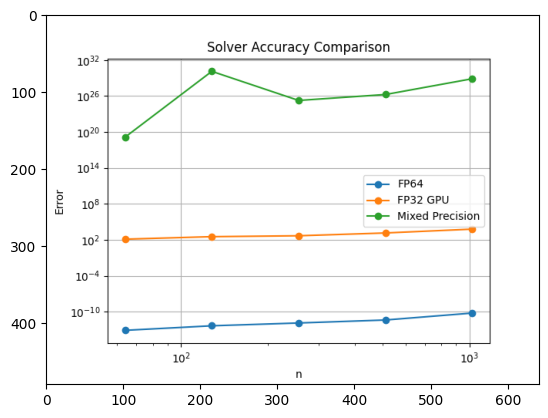

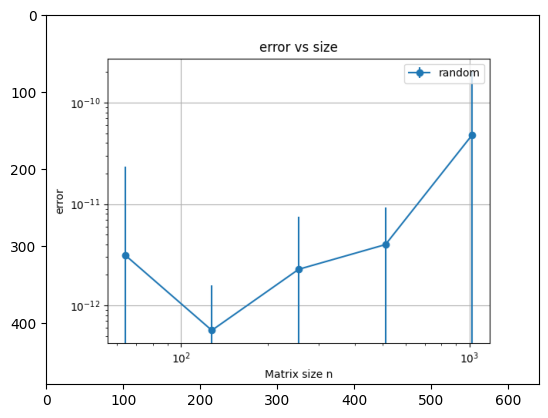

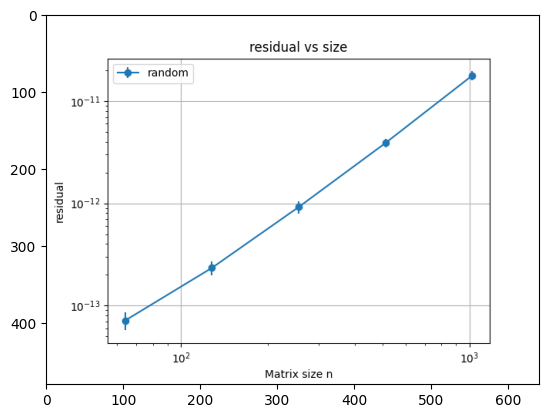

In [7]:
%cd /content/drive/MyDrive/mixed-precision-iterative-refinement-gpu/
%ls results/plots/
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('results/plots/comparison.png')
plt.imshow(img)
plt.show()

img = mpimg.imread('results/plots/baseline_error.png')
plt.imshow(img)
plt.show()

img = mpimg.imread('results/plots/baseline_residual.png')
plt.imshow(img)
plt.show()